**READ THE FILE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['patents_g06n3_wide.csv']

In [ ]:
import os
os.listdir('/content/drive/MyDrive/AIproject')

['patents_g06n3_wide.csv']

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords', quiet=True)

df = pd.read_csv("/content/drive/MyDrive/AIproject/patents_g06n3_wide.csv")

df['cpc_codes'] = df['cpc_codes'].fillna('').apply(lambda x: x.split('|') if x else [])
df['cited_patents'] = df['cited_patents'].fillna('').apply(lambda x: x.split('|') if x else [])

print(df.shape)
df.head()

(3000, 7)


,publication_number,filing_date,publication_date,title,abstract,cpc_codes,cited_patents
0,US-2024119857-A1,20220927,20240411,Systems and methods for training a scene simul...,"System, methods, and other embodiments describ...","[G06N3/0442, G06N3/0464, G06N3/096, G06N3/092,...","[US-2016314224-A1, US-2018275658-A1, US-201909..."
1,US-2023182019-A1,20230209,20230615,Multimodal experience modeling for gaming appl...,A system operates by generating BEA tools that...,"[G06N3/047, G06N3/048, G06N3/045, G06N3/08, G0...",[]
2,US-2021216862-A1,20200115,20210715,System and method for semantic analysis of mul...,A system and a method for multimedia data anal...,"[G06N3/08, G06N3/045, G06N3/045, G06N3/044, G0...",[]
3,US-2021169389-A1,20210107,20210610,Mood tracking and delivery of a therapeutic ba...,The system features a a method for mood tracki...,"[G06N3/0464, G06N3/08]",[]
4,US-10733085-B1,20180205,20200804,Detecting impedance mismatches due to cross-se...,Systems and methods are described for conducti...,[G06N3/02],"[US-4949254-A, US-5283888-A, US-5970488-A, US-..."


**CLEANING**

In [ ]:
PATENT_STOPWORDS = {
    'device', 'devices', 'method', 'methods', 'apparatus', 'apparatuses',
    'system', 'systems', 'configured', 'plurality', 'embodiment',
    'embodiments', 'disclosed', 'disclosure', 'provided', 'comprising',
    'comprise', 'comprises', 'invention', 'present', 'said', 'including',
    'include', 'includes', 'included', 'according', 'wherein', 'thereof',
    'therein', 'thereby', 'may', 'can', 'one', 'first', 'second', 'third',
    'least', 'example', 'examples', 'aspect', 'aspects', 'unit', 'units',
    'portion', 'portions', 'having', 'based', 'associated', 'using',
    'used', 'use', 'also', 'further', 'more', 'thus', 'via'
}

STOP_WORDS = set(stopwords.words('english')) | PATENT_STOPWORDS

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

df['clean_title'] = df['title'].apply(clean_text)
df['clean_abstract'] = df['abstract'].apply(clean_text)
df['clean_text'] = df['clean_title'] + ' ' + df['clean_abstract']

df['primary_cpc'] = df['cpc_codes'].apply(lambda codes: codes[0] if len(codes) > 0 else None)
df['primary_cpc_class'] = df['primary_cpc'].apply(lambda c: c[:4] if c else None)

df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print(df['clean_word_count'].describe())
print("\nRows with fewer than 10 words after cleaning:", (df['clean_word_count'] < 10).sum())

print("\n--- BEFORE ---")
print(df['abstract'].iloc[0][:300])
print("\n--- AFTER ---")
print(df['clean_text'].iloc[0][:300])

count    3000.000000
mean       66.624333
std        19.317650
min        12.000000
25%        53.000000
50%        67.000000
75%        80.000000
max       201.000000
Name: clean_word_count, dtype: float64

Rows with fewer than 10 words after cleaning: 0

--- BEFORE ---
System, methods, and other embodiments described herein relate to training a scene simulator for rendering 2D scenes using data from real and simulated agents. In one embodiment, a method includes acquiring trajectories and three-dimensional (3D) views for multiple agents from observations of real v

--- AFTER ---
training scene simulator real simulated agent data described herein relate training scene simulator rendering scenes data real simulated agents acquiring trajectories three dimensional views multiple agents observations real vehicles generating scene multiple agents views information simulated agent


**TF-IDF model + similarity**

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,     # cap vocabulary size to keep things manageable
    ngram_range=(1, 2),    # unigrams + bigrams (captures short phrases too)
    min_df=2               # ignore words that appear in fewer than 2 patents
)

tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)  # (num_patents, vocab_size)

# Full pairwise cosine similarity between every patent and every other
cosine_sim_matrix = cosine_similarity(tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim_matrix.shape)

# ============================================================
# Function: given a patent index, return top-k most similar patents
# ============================================================
def get_top_similar_tfidf(query_idx, top_k=5):
    sim_scores = list(enumerate(cosine_sim_matrix[query_idx]))
    sim_scores = [s for s in sim_scores if s[0] != query_idx]  # exclude itself
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:top_k]

    results = []
    for idx, score in sim_scores:
        results.append({
            'publication_number': df.iloc[idx]['publication_number'],
            'title': df.iloc[idx]['title'],
            'similarity': round(score, 4)
        })
    return pd.DataFrame(results)

# ============================================================
# Quick test on the first patent
# ============================================================
test_idx = 0
print("\nQuery patent:", df.iloc[test_idx]['publication_number'])
print("Title:", df.iloc[test_idx]['title'])
print("\nTop 5 most similar patents (TF-IDF):")
get_top_similar_tfidf(test_idx, top_k=5)

TF-IDF matrix shape: (3000, 5000)
Cosine similarity matrix shape: (3000, 3000)

Query patent: US-2024119857-A1
Title: Systems and methods for training a scene simulator using real and simulated agent data

Top 5 most similar patents (TF-IDF):


,publication_number,title,similarity
0,US-2022314993-A1,Top-down scene discrimination,0.4204
1,US-2024135197-A1,Generating enriched scenes using scene graphs,0.4151
2,US-11288884-B2,UAV real-time path planning method for urban s...,0.3907
3,US-2024221312-A1,Systems and methods for generating and/or usin...,0.3575
4,US-2023169852-A1,"Method, system and program product for trainin...",0.3380


##### **What the following code does:** What for every patent that cites another patent within our 3000-sample, we check whether TF-IDF's top-5/10/20 most similar results actually contain that true cited patent. Recall@k tells you what fraction of true citations get "found" if you only looked at the top k results, this is the actual accuracy metric we can report and compare against MiniLM later.

In [ ]:
# ============================================================
# Build citation ground truth: for each patent, which OTHER
# patents in our sample does it cite?
# ============================================================
sample_ids = set(df['publication_number'])
pub_to_idx = {pub: idx for idx, pub in enumerate(df['publication_number'])}

# Map: query patent index -> list of cited patent indices (that are IN our sample)
ground_truth = {}
for idx, row in df.iterrows():
    cited_in_sample = [pub_to_idx[c] for c in row['cited_patents'] if c in sample_ids]
    if cited_in_sample:
        ground_truth[idx] = cited_in_sample

print(f"Number of query patents with at least 1 in-sample citation: {len(ground_truth)}")
total_pairs = sum(len(v) for v in ground_truth.values())
print(f"Total citation pairs usable for evaluation: {total_pairs}")

# ============================================================
# Evaluation: for each query patent with known citations,
# check if TF-IDF ranks the true cited patent(s) near the top
# ============================================================
def evaluate_model(sim_matrix, ground_truth, k_values=[5, 10, 20]):
    results = {k: [] for k in k_values}

    for query_idx, true_cited in ground_truth.items():
        sim_scores = list(enumerate(sim_matrix[query_idx]))
        sim_scores = [s for s in sim_scores if s[0] != query_idx]
        ranked = [idx for idx, score in sorted(sim_scores, key=lambda x: x[1], reverse=True)]

        for k in k_values:
            top_k_set = set(ranked[:k])
            hits = len(top_k_set.intersection(true_cited))
            recall_at_k = hits / len(true_cited)
            results[k].append(recall_at_k)

    summary = {f"Recall@{k}": np.mean(v) for k, v in results.items()}
    return summary

tfidf_scores = evaluate_model(cosine_sim_matrix, ground_truth)
print("\n=== TF-IDF Evaluation (Recall@k against real citations) ===")
for metric, value in tfidf_scores.items():
    print(f"{metric}: {value:.4f}")

Number of query patents with at least 1 in-sample citation: 127
Total citation pairs usable for evaluation: 147

=== TF-IDF Evaluation (Recall@k against real citations) ===
Recall@5: 0.1903
Recall@10: 0.2165
Recall@20: 0.2559


**Build BM25 Model**

In [ ]:
!pip install rank_bm25 -q

In [ ]:
from rank_bm25 import BM25Okapi

# BM25 needs tokenized documents (list of word lists), not raw strings
tokenized_corpus = [doc.split() for doc in df['clean_text']]
bm25 = BM25Okapi(tokenized_corpus)

# ============================================================
# Build a full similarity-style matrix using BM25 scores
# (BM25 doesn't give a matrix directly - we query each patent
# against all others and collect scores)
# ============================================================
bm25_sim_matrix = np.zeros((len(df), len(df)))

for i in range(len(df)):
    query_tokens = tokenized_corpus[i]
    scores = bm25.get_scores(query_tokens)
    bm25_sim_matrix[i] = scores

print("BM25 similarity matrix shape:", bm25_sim_matrix.shape)

bm25_scores = evaluate_model(bm25_sim_matrix, ground_truth)
print("\n=== BM25 Evaluation (Recall@k against real citations) ===")
for metric, value in bm25_scores.items():
    print(f"{metric}: {value:.4f}")

BM25 similarity matrix shape: (3000, 3000)

=== BM25 Evaluation (Recall@k against real citations) ===
Recall@5: 0.1837
Recall@10: 0.2572
Recall@20: 0.2730


**TF-IDF + Truncated SVD**

In [ ]:
from sklearn.decomposition import TruncatedSVD

# ============================================================
# LSA: reduce TF-IDF matrix to latent dimensions via SVD
# ============================================================
n_components = 100  # number of latent topics/dimensions to keep

svd = TruncatedSVD(n_components=n_components, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)  # reuses the tfidf_matrix from earlier

print("LSA matrix shape:", lsa_matrix.shape)
print("Variance explained by these components:", round(svd.explained_variance_ratio_.sum(), 4))

lsa_sim_matrix = cosine_similarity(lsa_matrix)
print("LSA similarity matrix shape:", lsa_sim_matrix.shape)

lsa_scores = evaluate_model(lsa_sim_matrix, ground_truth)
print("\n=== LSA Evaluation (Recall@k against real citations) ===")
for metric, value in lsa_scores.items():
    print(f"{metric}: {value:.4f}")

LSA matrix shape: (3000, 100)
Variance explained by these components: 0.2424
LSA similarity matrix shape: (3000, 3000)

=== LSA Evaluation (Recall@k against real citations) ===
Recall@5: 0.1640
Recall@10: 0.1877
Recall@20: 0.2178


**MiniLM**

In [ ]:
!pip install sentence-transformers -q

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed the cleaned text
embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True, batch_size=32)
print("Embeddings shape:", embeddings.shape)

minilm_sim_matrix = cosine_similarity(embeddings)
print("MiniLM similarity matrix shape:", minilm_sim_matrix.shape)

minilm_scores = evaluate_model(minilm_sim_matrix, ground_truth)
print("\n=== MiniLM Evaluation (Recall@k against real citations) ===")
for metric, value in minilm_scores.items():
    print(f"{metric}: {value:.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Embeddings shape: (3000, 384)
MiniLM similarity matrix shape: (3000, 3000)

=== MiniLM Evaluation (Recall@k against real citations) ===
Recall@5: 0.1969
Recall@10: 0.2520
Recall@20: 0.3176


**COMPARISON CHART**

In [ ]:
# ============================================================
# Central results tracker - every model's Recall@k gets added here
# ============================================================
all_results = {
    'TF-IDF': tfidf_scores,
    'BM25': bm25_scores,
    'LSA' : lsa_scores,
    'MiniLM' : minilm_scores
}

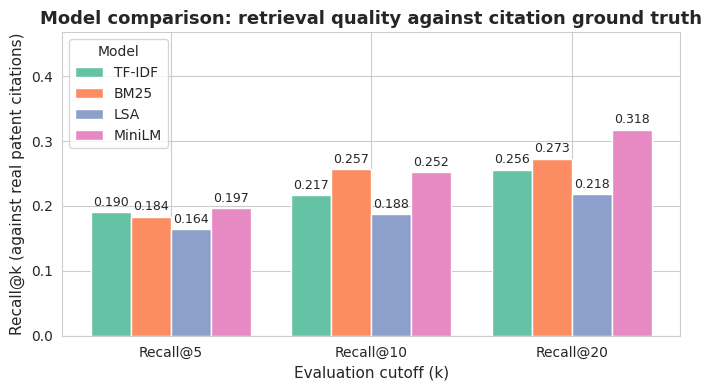

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_model_comparison(all_results):
    models = list(all_results.keys())
    k_values = list(next(iter(all_results.values())).keys())  # e.g. ['Recall@5', 'Recall@10', 'Recall@20']

    x = np.arange(len(k_values))
    width = 0.8 / len(models)  # bar width, adjusts automatically as models get added

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = sns.color_palette("Set2", len(models))

    for i, model in enumerate(models):
        values = [all_results[model][k] for k in k_values]
        bars = ax.bar(x + i * width, values, width, label=model, color=colors[i])
        # Add value labels on top of each bar
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha='center', va='bottom', fontsize=9)

    ax.set_xlabel("Evaluation cutoff (k)", fontsize=11)
    ax.set_ylabel("Recall@k (against real patent citations)", fontsize=11)
    ax.set_title("Model comparison: retrieval quality against citation ground truth", fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * (len(models)-1) / 2)
    ax.set_xticklabels(k_values)
    ax.legend(title="Model", loc='upper left')
    ax.set_ylim(0, max(max(v.values()) for v in all_results.values()) + 0.15)

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150)
    plt.show()

plot_model_comparison(all_results)

**SUMMARY**

In [ ]:
summary_df = pd.DataFrame(all_results).T
summary_df.columns = ['Recall@5', 'Recall@10', 'Recall@20']
summary_df = summary_df.round(4)
print(summary_df)

summary_df.to_csv("model_comparison_summary.csv")

        Recall@5  Recall@10  Recall@20
TF-IDF    0.1903     0.2165     0.2559
BM25      0.1837     0.2572     0.2730
LSA       0.1640     0.1877     0.2178
MiniLM    0.1969     0.2520     0.3176


### What it means:

* **MiniLM** (the semantic model) performed best overall, especially at Recall@20, but the gap over the lexical methods is small, not huge.
* **BM25** beats MiniLM at Recall@10, showing plain keyword-based search still holds up well.
* **LSA** was the weakest model. It compresses the data down and only kept 24% of the original information, which explains why it lost the most detail.
* Cleaning the text (removing boilerplate words) helped TF-IDF and BM25 a lot, but barely changed MiniLM's results since MiniLM understands full sentences, not just keywords.
* Even the best model only found about **32%** of true citations in the top 20 results. This is because patent citations are a legal decision, not just a text-similarity decision, so no model can fully predict them from text alone.